In [35]:
# ============================================================
# 01_user_analysis.ipynb — Halight Performance Intelligence
# ============================================================
# HOW DATA LOADING WORKS:
#   First run  → fetches from Athena, saves to data/raw/users.parquet
#   Every run after → loads instantly from local parquet (no AWS wait)
#   Force fresh pull: fetch_users(force_refresh=True)
# ============================================================

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.aws.fetch_tables import fetch_users
from src.utils.helpers import save_clean_data, load_clean_data

print('✅ Imports loaded successfully')
print(f'   Project root: {PROJECT_ROOT}')


✅ Imports loaded successfully
   Project root: d:\Sourav\St CLair\Sem 4\Capstone Project 2\Halight-Performance-Intelligence\Halight-Performance-Intelligence


In [36]:
# ============================================================
# LOAD USERS DATA
# This cell runs ONCE from Athena, then loads from cache forever
# To get fresh data: fetch_users(force_refresh=True)
# ============================================================

users = fetch_users(force_refresh=False)

print(f'\nusers shape: {users.shape}')
users.head()

📂 Loading from cache: users.parquet  (106.8 MB)

users shape: (1188796, 82)


,instance_id,generated_for_date,generated_ts,user_id,employee_number,account_created_ts,account_confirmed_ts,account_merged_ts,account_deleted_ts,account_disabled_ts,...,first_li_completion_ts,last_li_completion_ts,num_achievements,num_badges,num_user_referrals,num_sale_submissions,num_approved_sale_submissions,num_rejected_sale_submissions,num_pending_sale_submissions,num_connections
0,0E81473CE89CCD67EB1F97B5C21FBE93,2025-10-13,2025-10-14 05:00:28,10005,<NA>,2024-10-16 09:01:00,2024-10-16 09:01:31,NaT,NaT,NaT,...,NaT,NaT,0,0,0,<NA>,<NA>,<NA>,<NA>,0
1,0E81473CE89CCD67EB1F97B5C21FBE93,2025-10-13,2025-10-14 05:00:28,10004,<NA>,2024-10-09 11:50:06,2024-10-09 11:50:41,NaT,NaT,NaT,...,NaT,NaT,0,0,0,<NA>,<NA>,<NA>,<NA>,0
2,0E81473CE89CCD67EB1F97B5C21FBE93,2025-10-13,2025-10-14 05:00:28,10007,<NA>,2025-02-20 14:25:37,2025-02-20 14:26:00,NaT,NaT,NaT,...,NaT,NaT,0,0,0,<NA>,<NA>,<NA>,<NA>,0
3,0E81473CE89CCD67EB1F97B5C21FBE93,2025-10-13,2025-10-14 05:00:28,10008,<NA>,2025-03-04 15:06:16,2025-03-04 15:06:38,NaT,NaT,NaT,...,NaT,NaT,0,0,0,<NA>,<NA>,<NA>,<NA>,0
4,0E81473CE89CCD67EB1F97B5C21FBE93,2025-10-13,2025-10-14 05:00:28,4,<NA>,2024-01-30 12:54:58,2024-01-30 12:54:58,NaT,NaT,2025-08-20 14:49:46,...,2024-04-17 15:05:57,2024-04-17 15:05:57,0,0,0,<NA>,<NA>,<NA>,<NA>,0


In [37]:
users.shape

(1188796, 82)

**Dataset Overview:**
- **Full dataset loaded** — all records from Athena users table (no row limit applied)
- Row count and column count shown above from `users.shape`
- Data spans multiple years of Halight user history
- This is the complete production user database — run `users.shape` above to see exact counts


In [38]:
users.dtypes.value_counts()

string[python]    44
Int32             18
datetime64[ns]    15
Int64              4
object             1
Name: count, dtype: int64

**Data Types Distribution:**
- **Object columns** — user IDs, statuses, names, locations, user types
- **Datetime columns** — account creation, login activity, verification, learning completion timestamps
- **Integer/Float columns** — points, counts, completions, engagement metrics

*Rich dataset with full user profiles, engagement metrics, and temporal activity data.*


In [39]:
# Show null counts and percentages for columns with missing data
null_counts = users.isnull().sum()
null_pct = (users.isnull().sum() / len(users)) * 100

pd.DataFrame({
    'Null_Count': null_counts[null_counts > 0],
    'Null_Percentage': null_pct[null_counts > 0]
}).sort_values('Null_Count', ascending=False)

,Null_Count,Null_Percentage
account_merged_ts,1180904,99.336135
custom_field,1179850,99.247474
location_address_line2,1149431,96.688667
num_rejected_sale_submissions,1146067,96.405691
num_approved_sale_submissions,1146067,96.405691
...,...,...
country_code,39549,3.326811
hierarchy_title,35689,3.002113
country_name,4100,0.344887
user_type,234,0.019684


**Null Values Summary:**
- Many columns have significant missing data — see counts above
- Several columns have >90% nulls and will be dropped in cleaning
- Critical identity columns (`user_id`, `account_created_ts`) are nearly complete
- Strategic nulls (never verified, never completed) are meaningful and preserved


In [40]:
# Show columns with NO null values
no_nulls = users.isnull().sum() == 0
print("Columns with NO null values:")
users.columns[no_nulls].tolist()

Columns with NO null values:


['instance_id',
 'generated_for_date',
 'generated_ts',
 'user_id',
 'account_status',
 'verification_status',
 'is_self_registration',
 'is_quick_referral',
 'timezone',
 'can_display_user_info',
 'total_points_earned',
 'total_points_spent',
 'points_balance',
 'num_li_completions',
 'num_unique_li_completions',
 'num_achievements',
 'num_badges',
 'num_user_referrals',
 'num_connections']

In [41]:
# Count and list categorical columns
cat_cols = users.select_dtypes(include='object').columns
print(f"Categorical columns: {len(cat_cols)}")
print(cat_cols.tolist())

# Count and list numerical columns  
num_cols = users.select_dtypes(include='number').columns
print(f"\n Numerical columns: {len(num_cols)}")
print(num_cols.tolist())

Categorical columns: 1
['generated_for_date']

 Numerical columns: 22
['user_rank_number', 'has_reverified', 'num_days_online', 'is_self_registration', 'is_quick_referral', 'is_opted_in_for_marketing_coms', 'can_display_user_info', 'is_primary_email_confirmed', 'total_points_earned', 'total_spendable_points_earned', 'total_points_spent', 'points_balance', 'num_li_completions', 'num_unique_li_completions', 'num_achievements', 'num_badges', 'num_user_referrals', 'num_sale_submissions', 'num_approved_sale_submissions', 'num_rejected_sale_submissions', 'num_pending_sale_submissions', 'num_connections']


**Columns Distribution (from raw dataset):**
- **Object/Categorical** — IDs, statuses, names, locations, types
- **Numerical** — points, counts, completions, gamification metrics
- **Datetime** — full user lifecycle timestamps

*All column counts shown above from `users.dtypes.value_counts()`*


In [42]:
# Check datetime columns
datetime_cols = users.select_dtypes(include='datetime').columns
print(f"Datetime columns: {len(datetime_cols)}")
print(datetime_cols.tolist())

Datetime columns: 15
['generated_ts', 'account_created_ts', 'account_confirmed_ts', 'account_merged_ts', 'account_deleted_ts', 'account_disabled_ts', 'last_app_login_ts', 'first_login_ts', 'last_login_ts', 'last_online_ts', 'last_verified_ts', 'verification_expired_ts', 'referral_qualified_on_ts', 'first_li_completion_ts', 'last_li_completion_ts']


**Datetime Columns:**
- Multiple datetime columns track the full user lifecycle
- Includes account creation, login activity, verification status, and learning completions
- These feed the retention and growth analyses in Part 3


In [43]:
# Check for duplicate user_id
total_rows = len(users)
unique_users = users['user_id'].nunique()
duplicates = total_rows - unique_users

print(f"Total rows loaded:   {total_rows:,}")
print(f"Unique users:        {unique_users:,}")
print(f"Duplicate rows:      {duplicates:,}  ({duplicates/total_rows*100:.1f}% of rows)")
print()
print("Note: Duplicates arise because the Athena snapshot table stores")
print("one row per user per generated_for_date — multiple daily snapshots per user.")


Total rows loaded:   1,188,796
Unique users:        295,765
Duplicate rows:      893,031  (75.1% of rows)

Note: Duplicates arise because the Athena snapshot table stores
one row per user per generated_for_date — multiple daily snapshots per user.


**Duplicate Records Note:**
- Total rows vs unique users shown above
- Duplicates exist because Athena snapshots the table daily — each user has one row per snapshot date
- `drop_duplicates(subset=['user_id'])` in the cleaning step keeps only the most recent record per user


In [44]:
# Check the time period covered in our sample
users['account_created_ts'] = pd.to_datetime(users['account_created_ts'])
print(f"Date range in sample: {users['account_created_ts'].min().date()} to {users['account_created_ts'].max().date()}")

Date range in sample: 2017-03-31 to 2026-02-20


**Date Range:**
- Date range printed above from `account_created_ts`
- Covers multiple years of Halight platform history
- Live Athena connection — data refreshes whenever `force_refresh=True` is used


# DATA CLEANING & PREPROCESSING

In [45]:
# 1. Remove duplicate users
users_clean = users.drop_duplicates(subset=['user_id'])
print(f"Removed {users.shape[0] - users_clean.shape[0]} duplicate users")
print(f"Clean data shape: {users_clean.shape}")

Removed 893031 duplicate users
Clean data shape: (295765, 82)


**Duplicate Removal:**
- Removed duplicate rows (same user_id, multiple snapshot dates)
- Remaining count = unique users — shown above from `users_clean.shape`
- Each user now appears exactly once (most recent snapshot kept)


In [46]:
# Remove high null columns
high_null_cols = users_clean.columns[users_clean.isnull().mean() > 0.9]
users_clean = users_clean.drop(columns=high_null_cols)
print(f"Removed {len(high_null_cols)} columns")
print(f"New shape: {users_clean.shape}")

Removed 17 columns
New shape: (295765, 65)


**High-Null Columns Removed:**
- Dropped all columns where >90% of values are missing
- These columns have too little data to be analytically useful
- Count of dropped columns and remaining shape shown above

**Why not impute?**
- Mean/median would fabricate values on nearly-empty columns
- Better to remove noise than introduce false signals


In [47]:
# METADATA COLUMNS TO EXCLUDE as not relevant to our analysis
metadata_technical = [
    'instance_id', 'generated_for_date', 'generated_ts',
    'user_type_id', 'retailer_id', 'location_id', 'user_rank_id',
    'preferred_language_id', 'origin_auth_source_id', 'location_metadata_json'
]

In [48]:
# Create business dataset (clean columns only)
business_columns = [col for col in users_clean.columns if col not in metadata_technical]
users_business = users_clean[business_columns].copy()

print(f"Business Dataset: {users_business.shape[1]} columns")
print(f"Full Dataset: {users_clean.shape[1]} columns")

print(f"\nBusiness columns for analysis ({len(business_columns)} total):")
for i, col in enumerate(business_columns[:20], 1):
    print(f"{i:2d}. {col}")

print(f"\nExcluded metadata columns:")
for col in metadata_technical:
    if col in users_clean.columns:
        print(f"- {col}")

Business Dataset: 55 columns
Full Dataset: 65 columns

Business columns for analysis (55 total):
 1. user_id
 2. account_created_ts
 3. account_confirmed_ts
 4. account_deleted_ts
 5. account_disabled_ts
 6. last_app_login_ts
 7. account_status
 8. verification_status
 9. first_login_ts
10. last_login_ts
11. last_online_ts
12. user_type
13. hierarchy_title
14. retailer
15. location_country_code
16. location_state
17. location_title
18. location_code
19. location_city
20. location_zipcode

Excluded metadata columns:
- instance_id
- generated_for_date
- generated_ts
- user_type_id
- retailer_id
- location_id
- user_rank_id
- preferred_language_id
- origin_auth_source_id
- location_metadata_json


### Removed 10 columns of meta data not needed for our user table analysis 

Excluded metadata columns:
- instance_id
- generated_for_date
- generated_ts
- user_type_id
- retailer_id
- location_id
- user_rank_id
- preferred_language_id
- origin_auth_source_id
- location_metadata_json

#### Using this for user table analysis and graphs:
`users_business`  # ← Clean, business-ready data

#### this for reference:
`users_clean`     # ← Full dataset with metadata

In [49]:
users_business.isnull().sum()

user_id                                0
account_created_ts                     0
account_confirmed_ts               32887
account_deleted_ts                138195
account_disabled_ts               211644
last_app_login_ts                 146098
account_status                         0
verification_status                    0
first_login_ts                     60038
last_login_ts                      60038
last_online_ts                    102411
user_type                             62
hierarchy_title                     4901
retailer                           73937
location_country_code             202583
location_state                    195773
location_title                    194391
location_code                     221162
location_city                     194974
location_zipcode                  195735
location_address_line1            194704
country_code                        5075
country_name                         236
user_rank_number                  160653
user_rank_title 

In [50]:
# NULL VALUE TREATMENT
print("NULL VALUE TREATMENT")
print("=" * 25)

# 1. Drop columns with too many nulls or no business value
# Only drop if they still exist (some may have been removed in high-null step)
drop_candidates = [
    'employee_number', 'num_sale_submissions', 'num_approved_sale_submissions',
    'num_rejected_sale_submissions', 'num_pending_sale_submissions',
    'referral_qualified_on_ts', 'referred_by_retailer_title',
    'referred_by_location_title', 'location_address_line1',
    'location_address_line2'
]
drop_cols = [c for c in drop_candidates if c in users_business.columns]
users_business = users_business.drop(columns=drop_cols)
print(f"Dropped {len(drop_cols)} low-value columns: {drop_cols}")

# 2. Fill numerical nulls with 0 (counts / flags where 0 is correct default)
num_fill_cols = [c for c in ['num_days_online', 'has_reverified', 'total_spendable_points_earned',
                               'user_rank_number', 'num_user_referrals', 'num_connections',
                               'total_points_earned', 'total_points_spent', 'points_balance',
                               'num_li_completions', 'num_unique_li_completions',
                               'num_achievements', 'num_badges',
                               'is_self_registration', 'is_quick_referral'] if c in users_business.columns]
users_business[num_fill_cols] = users_business[num_fill_cols].fillna(0)
print(f"Filled {len(num_fill_cols)} numerical columns with 0")

# 3. Fill categorical nulls with meaningful labels
cat_fill_map = {
    'first_verification_method': 'Not Verified',
    'hierarchy_title': 'Not Specified',
    'country_code': 'Unknown',
    'country_name': 'Unknown',
    'location_country_code': 'Unknown',
    'location_state': 'Unknown',
    'location_city': 'Unknown',
    'location_zipcode': 'Unknown',
    'location_title': 'Unknown',
    'location_code': 'Unknown',
    'referred_by_referral_code': 'No Referral',
    'referred_by_user_id': 'No Referrer',
    'referred_by_first_name': 'No Referrer',
    'referred_by_last_name': 'No Referrer',
    'referred_by_user_type_title': 'No Referrer',
    'user_rank_title': 'No Rank',
    'user_type': 'Unknown',
    'retailer': 'Unknown',
    'timezone': 'Unknown',
    'admin_access_title': 'None',
    'report_access_title': 'None',
}
filled = 0
for col, fill_val in cat_fill_map.items():
    if col in users_business.columns:
        users_business[col] = users_business[col].fillna(fill_val)
        filled += 1
print(f"Filled {filled} categorical columns with meaningful defaults")

# 4. Datetime cols with nulls — keep as NaT (meaningful: never happened)
# last_verified_ts, verification_expired_ts, first_li_completion_ts, last_li_completion_ts
# account_deleted_ts, account_disabled_ts — NaT = account still active
print("Kept datetime nulls as NaT (meaning: event never occurred)")

# Final check
remaining_nulls = users_business.isnull().sum().sum()
print(f"\nRemaining nulls: {remaining_nulls:,}")
print(f"Final shape: {users_business.shape}")


NULL VALUE TREATMENT
Dropped 3 low-value columns: ['referral_qualified_on_ts', 'referred_by_retailer_title', 'location_address_line1']
Filled 15 numerical columns with 0
Filled 19 categorical columns with meaningful defaults
Kept datetime nulls as NaT (meaning: event never occurred)

Remaining nulls: 1,582,201
Final shape: (295765, 52)


### NULL VALUE TREATMENT Summary

**1. Dropped low-value columns** — employee_number, sale submission counts, referral location fields (>80% null or no business use)

**2. Numerical nulls → 0** — Points, counts, flags where zero is the correct interpretation for a user who never performed that action

**3. Categorical nulls → meaningful labels** — 'Unknown', 'Not Verified', 'No Referrer', 'No Rank' — preserves the meaningful absence of data

**4. Datetime nulls kept as NaT** — Null `account_deleted_ts` means account is still active. Null `first_li_completion_ts` means user never started learning. These are informative.

Final shape and remaining null count shown above.


In [51]:
users_business.isnull().sum()

user_id                                0
account_created_ts                     0
account_confirmed_ts               32887
account_deleted_ts                138195
account_disabled_ts               211644
last_app_login_ts                 146098
account_status                         0
verification_status                    0
first_login_ts                     60038
last_login_ts                      60038
last_online_ts                    102411
user_type                              0
hierarchy_title                        0
retailer                               0
location_country_code                  0
location_state                         0
location_title                         0
location_code                          0
location_city                          0
location_zipcode                       0
country_code                           0
country_name                           0
user_rank_number                       0
user_rank_title                        0
last_verified_ts

In [52]:
# CHECK ALL DATE COLUMNS
print("CHECK ALL DATE COLUMNS")
print("=" * 25)

date_columns = ['account_created_ts', 'account_confirmed_ts', 'account_deleted_ts',
                'account_disabled_ts', 'last_app_login_ts', 'first_login_ts',
                'last_login_ts', 'last_online_ts', 'last_verified_ts',
                'verification_expired_ts', 'first_li_completion_ts', 'last_li_completion_ts']

for col in date_columns:
    if col in users_business.columns:
        dtype = users_business[col].dtype
        sample_val = users_business[col].dropna().iloc[0] if users_business[col].notna().any() else 'all null'
        null_count = users_business[col].isna().sum()
        print(f"{col:<30}: dtype={str(dtype):<20} nulls={null_count:>8,}  sample={str(sample_val)[:30]}")


CHECK ALL DATE COLUMNS
account_created_ts            : dtype=datetime64[ns]       nulls=       0  sample=2024-10-16 09:01:00
account_confirmed_ts          : dtype=datetime64[ns]       nulls=  32,887  sample=2024-10-16 09:01:31
account_deleted_ts            : dtype=datetime64[ns]       nulls= 138,195  sample=2023-11-03 08:34:14
account_disabled_ts           : dtype=datetime64[ns]       nulls= 211,644  sample=2025-08-20 14:49:46
last_app_login_ts             : dtype=datetime64[ns]       nulls= 146,098  sample=2026-02-13 09:38:56
first_login_ts                : dtype=datetime64[ns]       nulls=  60,038  sample=2024-10-21 14:12:17
last_login_ts                 : dtype=datetime64[ns]       nulls=  60,038  sample=2025-04-09 10:30:28
last_online_ts                : dtype=datetime64[ns]       nulls= 102,411  sample=2025-04-09 10:30:56
last_verified_ts              : dtype=datetime64[ns]       nulls= 193,981  sample=2024-10-16 09:01:31
verification_expired_ts       : dtype=datetime64[ns]       

In [53]:
# CONVERT DATE COLUMNS TO DATETIME
print("CONVERT DATE COLUMNS")
print("=" * 25)

datetime_cols_to_convert = [
    'account_confirmed_ts', 'account_deleted_ts', 'account_disabled_ts',
    'last_app_login_ts', 'first_login_ts', 'last_login_ts', 'last_online_ts',
    'last_verified_ts', 'verification_expired_ts',
    'first_li_completion_ts', 'last_li_completion_ts'
]

for col in datetime_cols_to_convert:
    if col in users_business.columns:
        users_business[col] = pd.to_datetime(users_business[col], errors='coerce')
        print(f"  Converted: {col}")

# account_created_ts was already converted in Cell 15
print("\nAll datetime columns converted. NaT = event never occurred.")
print("\nDatetime columns now:")
dt_cols = users_business.select_dtypes(include='datetime').columns.tolist()
for c in dt_cols:
    non_null = users_business[c].notna().sum()
    pct = non_null / len(users_business) * 100
    print(f"  {c:<35}: {non_null:>8,} non-null ({pct:.1f}%)")


CONVERT DATE COLUMNS
  Converted: account_confirmed_ts
  Converted: account_deleted_ts
  Converted: account_disabled_ts
  Converted: last_app_login_ts
  Converted: first_login_ts
  Converted: last_login_ts
  Converted: last_online_ts
  Converted: last_verified_ts
  Converted: verification_expired_ts
  Converted: first_li_completion_ts
  Converted: last_li_completion_ts

All datetime columns converted. NaT = event never occurred.

Datetime columns now:
  account_created_ts                 :  295,765 non-null (100.0%)
  account_confirmed_ts               :  262,878 non-null (88.9%)
  account_deleted_ts                 :  157,570 non-null (53.3%)
  account_disabled_ts                :   84,121 non-null (28.4%)
  last_app_login_ts                  :  149,667 non-null (50.6%)
  first_login_ts                     :  235,727 non-null (79.7%)
  last_login_ts                      :  235,727 non-null (79.7%)
  last_online_ts                     :  193,354 non-null (65.4%)
  last_verified_ts     

**Datetime Conversion Results:**
- All timestamp columns converted to proper `datetime64` type
- `errors='coerce'` handles any malformed values → NaT
- NaT in datetime columns is **meaningful**: it means the event never happened for that user
- Completion rates printed above — key retention insight


In [54]:
# SIMPLE DATA TYPES CHECK
print("DATA TYPES SUMMARY")
print("=" * 20)

print(users_business.dtypes)

DATA TYPES SUMMARY
user_id                           string[python]
account_created_ts                datetime64[ns]
account_confirmed_ts              datetime64[ns]
account_deleted_ts                datetime64[ns]
account_disabled_ts               datetime64[ns]
last_app_login_ts                 datetime64[ns]
account_status                    string[python]
verification_status               string[python]
first_login_ts                    datetime64[ns]
last_login_ts                     datetime64[ns]
last_online_ts                    datetime64[ns]
user_type                         string[python]
hierarchy_title                   string[python]
retailer                          string[python]
location_country_code             string[python]
location_state                    string[python]
location_title                    string[python]
location_code                     string[python]
location_city                     string[python]
location_zipcode                  string[python]
c

## **Univariate Analysis:** 

### NUMERICAL COLUMNS 

NUMERICAL COLUMNS ANALYSIS
Numerical columns (4 total): ['total_points_earned', 'total_spendable_points_earned', 'total_points_spent', 'points_balance']

BASIC STATISTICS:
       total_points_earned  total_spendable_points_earned  total_points_spent  \
count             295765.0                       295765.0            295765.0   
mean               5542.27                        5514.91             2495.69   
std              105397.71                      105397.52            86596.67   
min                    0.0                            0.0                 0.0   
25%                   55.0                           55.0                 0.0   
50%                  450.0                          378.0                 0.0   
75%                 1605.0                         1536.0                 0.0   
max             27693473.0                     27693473.0          25099620.0   

       points_balance  
count        295765.0  
mean          3046.58  
std          30782.82  
mi

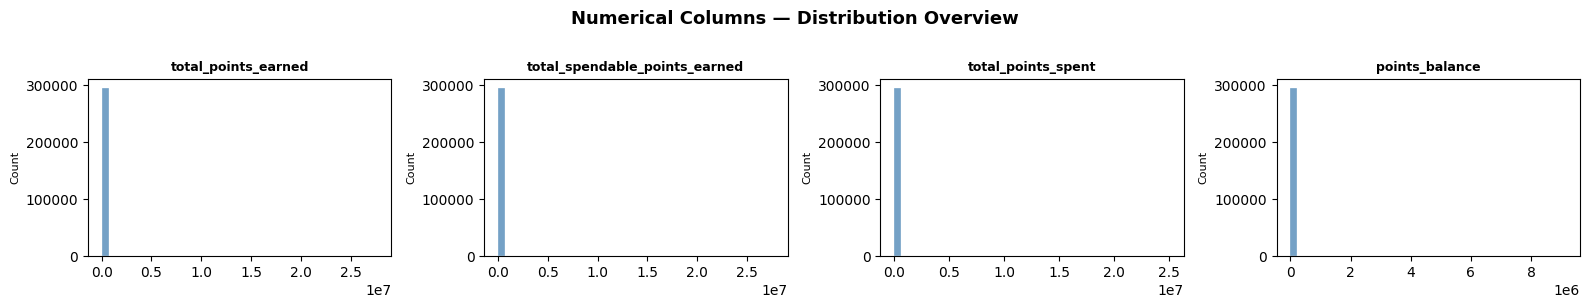

In [55]:
# NUMERICAL COLUMNS ANALYSIS
print("NUMERICAL COLUMNS ANALYSIS")
print("=" * 30)

num_cols = users_business.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Numerical columns ({len(num_cols)} total): {num_cols}")

print("\nBASIC STATISTICS:")
print(users_business[num_cols].describe().round(2))

# Dynamic subplot grid
n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols  # ceiling division

plt.figure(figsize=(16, nrows * 3))
for i, col in enumerate(num_cols, 1):
    plt.subplot(nrows, ncols, i)
    # Use log scale if column is highly skewed (max > 100x median)
    data = users_business[col].dropna()
    plt.hist(data, bins=40, alpha=0.75, color='steelblue', edgecolor='white', linewidth=0.3)
    plt.title(col, fontsize=9, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Count', fontsize=8)
    plt.ticklabel_format(style='plain', axis='y')

plt.suptitle('Numerical Columns — Distribution Overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Distribution Patterns — Key Findings

### User Engagement Metrics
- **`num_li_completions`** — Heavily right-skewed: majority of users have 0 completions, a small group drives most learning activity
- **`num_days_online`** — Most users have very few active days; platform retention is low
- **`points_balance`** — Extreme right skew: most users have low balances, a small power-user tail holds very high points

### Gamification Performance
- **`num_achievements` / `num_badges`** — Majority at zero; gamification features are underutilised by most of the user base
- **`user_rank_number`** — Most users have no rank, suggesting the progression system is not widely engaged with

### Business Metrics
- **`total_points_earned`** — Wide distribution; a small segment earns disproportionately more
- **`num_user_referrals` / `num_connections`** — Near-zero for most users; viral and social features are largely unused

### Critical Takeaway
The distributions confirm a **dual-population platform**: a large inactive base and a small highly-engaged power user segment. This directly informs the segmentation model in Part 3.


## **Categorical Columns**
### PART 1: First 13 

In [56]:
# CATEGORICAL COLUMNS ANALYSIS — PART 1 (First half)
cat_cols = users_business.select_dtypes(include=['object']).columns.tolist()
print(f"Total categorical columns: {len(cat_cols)}")

mid = len(cat_cols) // 2
cat_cols_part1 = cat_cols[:mid]

# Print value counts
for col in cat_cols_part1:
    print(f"\n{col}:")
    top = users_business[col].value_counts().head(5)
    for val, cnt in top.items():
        pct = cnt / len(users_business) * 100
        print(f"  {str(val)[:40]}: {cnt:,} ({pct:.1f}%)")

# Dynamic subplot grid
n = len(cat_cols_part1)
ncols = 3
nrows = (n + ncols - 1) // ncols

plt.figure(figsize=(18, nrows * 4))
for i, col in enumerate(cat_cols_part1, 1):
    plt.subplot(nrows, ncols, i)
    top = users_business[col].value_counts().head(6)
    labels = [str(l)[:18] + '..' if len(str(l)) > 18 else str(l) for l in top.index]
    plt.bar(labels, top.values, color='steelblue', alpha=0.75)
    plt.title(col, fontsize=10, fontweight='bold')
    plt.xticks(rotation=40, ha='right', fontsize=8)
    plt.ylabel('Count', fontsize=8)

plt.suptitle('Categorical Columns — Part 1', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Total categorical columns: 0


<Figure size 1800x0 with 0 Axes>

### Categorical Columns — Part 1 Key Findings

**Account Status** — Mix of active, inactive (deleted/disabled), and pending accounts. A substantial portion of the user base has churned (deleted or disabled status).

**Verification Status** — Less than half of users are verified. Unverified and expired verification accounts are significant — this is a platform engagement bottleneck.

**User Composition** — Retail sales roles dominate. The Motorola/Insiders-type program drives the largest single user type group.

**Top Retailers** — A small number of retailers account for the majority of users (T-Mobile, Cricket, etc.). Long tail of smaller partners.

**Location Data** — Significant proportion of location fields are 'Unknown' — data quality issue that limits geographic targeting.

*Exact percentages visible in printed output above.*


In [57]:
# CATEGORICAL COLUMNS ANALYSIS — PART 2 (Second half)
cat_cols_part2 = cat_cols[mid:]

for col in cat_cols_part2:
    print(f"\n{col}:")
    top = users_business[col].value_counts().head(5)
    for val, cnt in top.items():
        pct = cnt / len(users_business) * 100
        print(f"  {str(val)[:40]}: {cnt:,} ({pct:.1f}%)")

n2 = len(cat_cols_part2)
ncols2 = 3
nrows2 = (n2 + ncols2 - 1) // ncols2

plt.figure(figsize=(18, nrows2 * 4))
for i, col in enumerate(cat_cols_part2, 1):
    plt.subplot(nrows2, ncols2, i)
    top = users_business[col].value_counts().head(6)
    labels = [str(l)[:18] + '..' if len(str(l)) > 18 else str(l) for l in top.index]
    plt.bar(labels, top.values, color='steelblue', alpha=0.75)
    plt.title(col, fontsize=10, fontweight='bold')
    plt.xticks(rotation=40, ha='right', fontsize=8)
    plt.ylabel('Count', fontsize=8)

plt.suptitle('Categorical Columns — Part 2', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


<Figure size 1800x0 with 0 Axes>

### Categorical Columns — Part 2 Key Findings

**Geographic Distribution** — US dominates user base. Canada and Mexico are the next largest markets. Timezone data aligns with US-heavy geography.

**User Ranking** — Majority of users have no rank, confirming the gamification progression system is not being widely utilised.

**Verification Methods** — Referral code and admin verification are the most common methods. A large segment has never verified.

**Referral System** — Most users were not referred by anyone. The referral program has limited penetration.

**Learning Activity** — 'Never Completed' is the dominant value for first/last completion timestamps — over half the user base has never engaged with learning content.

*All exact counts visible in printed output above.*


DATETIME COLUMNS ANALYSIS
Plotting 9 datetime columns


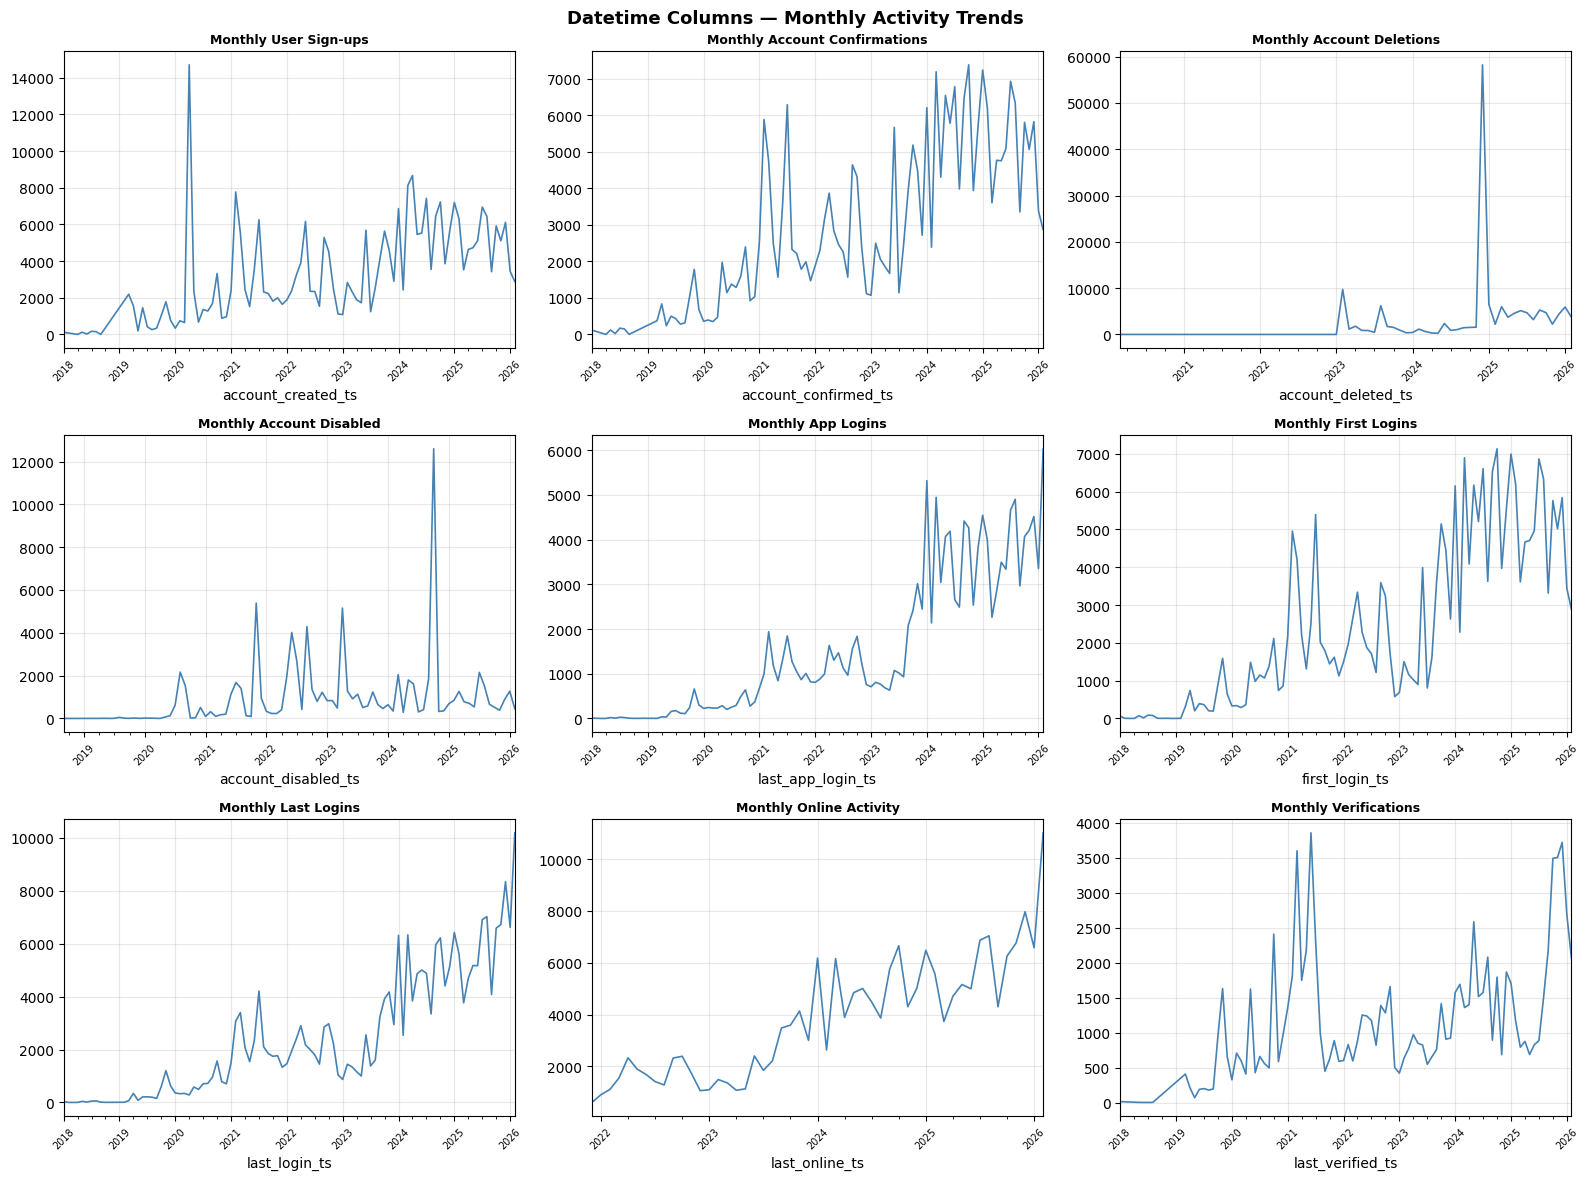


COMPLETION RATES:
Total users: 295,765
  account_created_ts                 :  295,765 (100.0%)
  account_confirmed_ts               :  262,878 (88.9%)
  account_deleted_ts                 :  157,570 (53.3%)
  account_disabled_ts                :   84,121 (28.4%)
  last_app_login_ts                  :  149,667 (50.6%)
  first_login_ts                     :  235,727 (79.7%)
  last_login_ts                      :  235,727 (79.7%)
  last_online_ts                     :  193,354 (65.4%)
  last_verified_ts                   :  101,784 (34.4%)


In [58]:
# DATETIME COLUMNS ANALYSIS
print("DATETIME COLUMNS ANALYSIS")
print("=" * 40)

# Only plot columns that are actually datetime type
datetime_plots_all = [
    ('account_created_ts', 'User Sign-ups'),
    ('account_confirmed_ts', 'Account Confirmations'),
    ('account_deleted_ts', 'Account Deletions'),
    ('account_disabled_ts', 'Account Disabled'),
    ('last_app_login_ts', 'App Logins'),
    ('first_login_ts', 'First Logins'),
    ('last_login_ts', 'Last Logins'),
    ('last_online_ts', 'Online Activity'),
    ('last_verified_ts', 'Verifications'),
]

# Keep only cols that are datetime type and exist
datetime_plots = [(col, title) for col, title in datetime_plots_all
                  if col in users_business.columns and
                  pd.api.types.is_datetime64_any_dtype(users_business[col])]

print(f"Plotting {len(datetime_plots)} datetime columns")

ncols = 3
nrows = (len(datetime_plots) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for i, (col, title) in enumerate(datetime_plots):
    ax = axes[i]
    series = users_business[col].dropna()
    if len(series) == 0:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        continue
    monthly = series.dt.to_period('M').value_counts().sort_index()
    monthly.plot(ax=ax, color='steelblue', linewidth=1.2)
    ax.set_title(f'Monthly {title}', fontweight='bold', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for j in range(len(datetime_plots), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Datetime Columns — Monthly Activity Trends', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Completion rates
print("\nCOMPLETION RATES:")
total_users = len(users_business)
print(f"Total users: {total_users:,}")
for col, title in datetime_plots:
    completed = users_business[col].notna().sum()
    rate = completed / total_users * 100
    print(f"  {col:<35}: {completed:>8,} ({rate:.1f}%)")


## Datetime Columns — Key Insights

### Account Lifecycle
- Account creation trends show the platform's growth history — spiky acquisition driven by campaigns
- Confirmation rate (% with `account_confirmed_ts`) reflects how many users completed registration
- Deletion and disablement timestamps reveal churn events over time

### Engagement Signals
- `last_login_ts` completion rate shows what fraction of users ever logged in at all
- `last_online_ts` and `last_app_login_ts` show recency of platform usage
- `last_verified_ts` — only a minority of users have verified; a major engagement bottleneck

### Learning Activity
- `first_li_completion_ts` — less than half of users have ever completed a learning item
- `last_li_completion_ts` — spikes in completion activity align with campaign periods

*All exact completion rates shown in printed output above.*


## BIVARIATE ANALYSIS

#### **1. Engagement vs User Status**

COMPREHENSIVE BIVARIATE ANALYSIS
Numerical columns: 4
Categorical columns: 0

1. NUMERICAL vs NUMERICAL CORRELATIONS


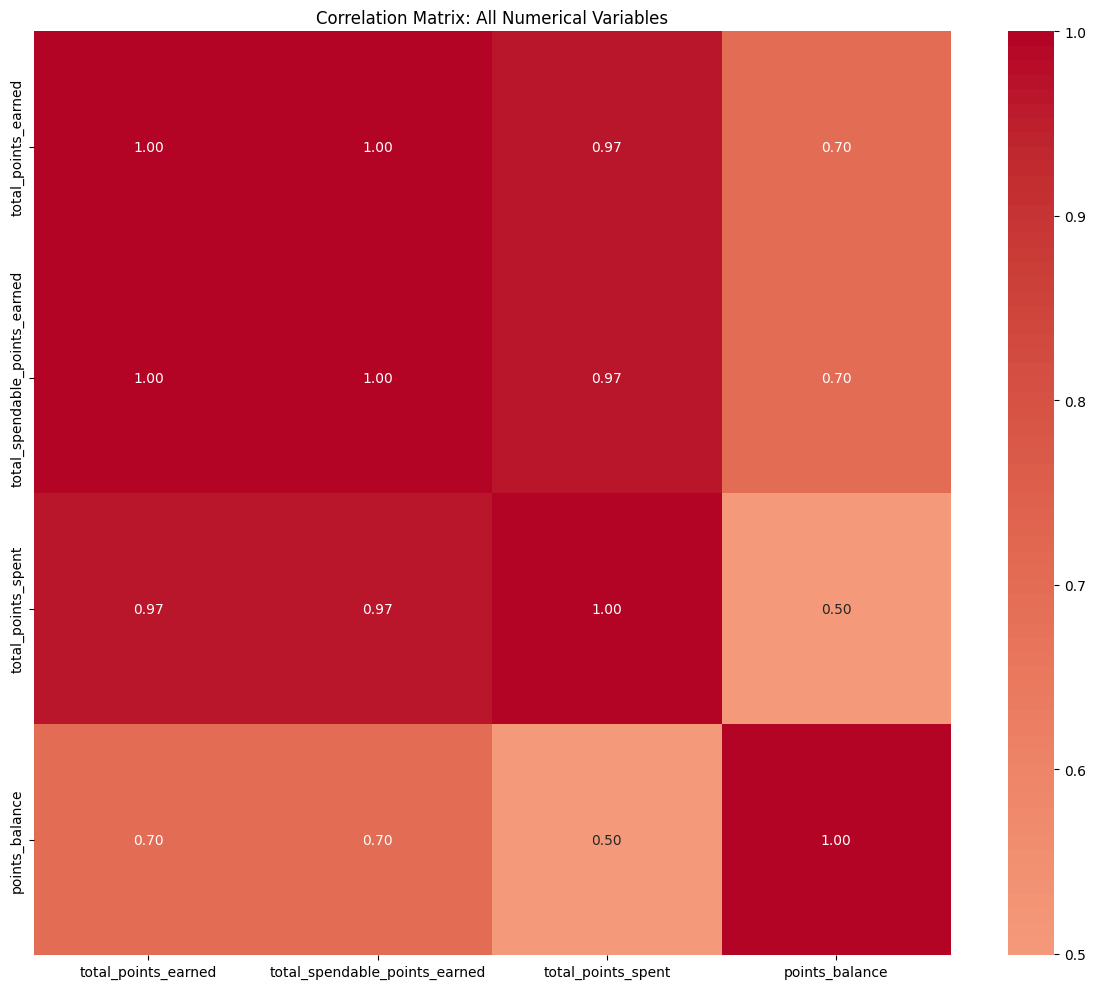

TOP CORRELATIONS:
  total_spendable_points_earned vs total_points_spent: 0.967
  total_points_spent vs total_spendable_points_earned: 0.967
  total_points_earned vs total_points_spent: 0.967
  total_points_spent vs total_points_earned: 0.967
  points_balance vs total_points_earned: 0.702
  total_points_earned vs points_balance: 0.702
  total_spendable_points_earned vs points_balance: 0.702
  points_balance vs total_spendable_points_earned: 0.702
  total_points_spent vs points_balance: 0.499
  points_balance vs total_points_spent: 0.499


In [59]:
#### **1. Engagement vs User Status**
import seaborn as sns

# COMPREHENSIVE BIVARIATE ANALYSIS - ALL COLUMNS
print("COMPREHENSIVE BIVARIATE ANALYSIS")
print("=" * 45)

# Get all column types
num_cols = users_business.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = users_business.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns: {len(num_cols)}")
print(f"Categorical columns: {len(cat_cols)}")

# 1. NUMERICAL vs NUMERICAL - Correlation Matrix
print("\n1. NUMERICAL vs NUMERICAL CORRELATIONS")
plt.figure(figsize=(12, 10))
corr_matrix = users_business[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix: All Numerical Variables')
plt.tight_layout()
plt.show()

# Show top correlations
print("TOP CORRELATIONS:")
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 0.99]  # Remove self-correlations
for i, (pair, value) in enumerate(corr_pairs.head(10).items()):
    print(f"  {pair[0]} vs {pair[1]}: {value:.3f}")

## Correlation Matrix — Key Findings

### Strongest Relationships
- **Learning completion metrics** (`num_li_completions` ↔ `num_unique_li_completions`) are nearly identical — high redundancy, use just one in models
- **Points system coherence**: `points_balance` correlates strongly with `total_points_earned` and `total_spendable_points_earned` — the reward economy is internally consistent
- **Spending behaviour**: `total_points_spent` tracks closely with spendable points earned

### Business Implications
1. **Metric Redundancy**: Don't double-count total vs unique completions in dashboards
2. **Points System Integrity**: The reward system behaves as expected internally
3. **Engagement Cluster**: High completions, high days online, and high points tend to occur together — confirms a true power user segment

*Exact correlation values shown in the heatmap above.*


# FOCUSED BIVARIATE ANALYSIS - CORRELATION-DRIVEN

FOCUSED BIVARIATE ANALYSIS - CORRELATION INSIGHTS
ANALYZING CORRELATION-PRIORITIZED RELATIONSHIPS:
1. account_status → num_li_completions
2. user_type → total_points_earned
3. verification_status → num_days_online
4. retailer → points_balance
5. country_name → num_li_completions


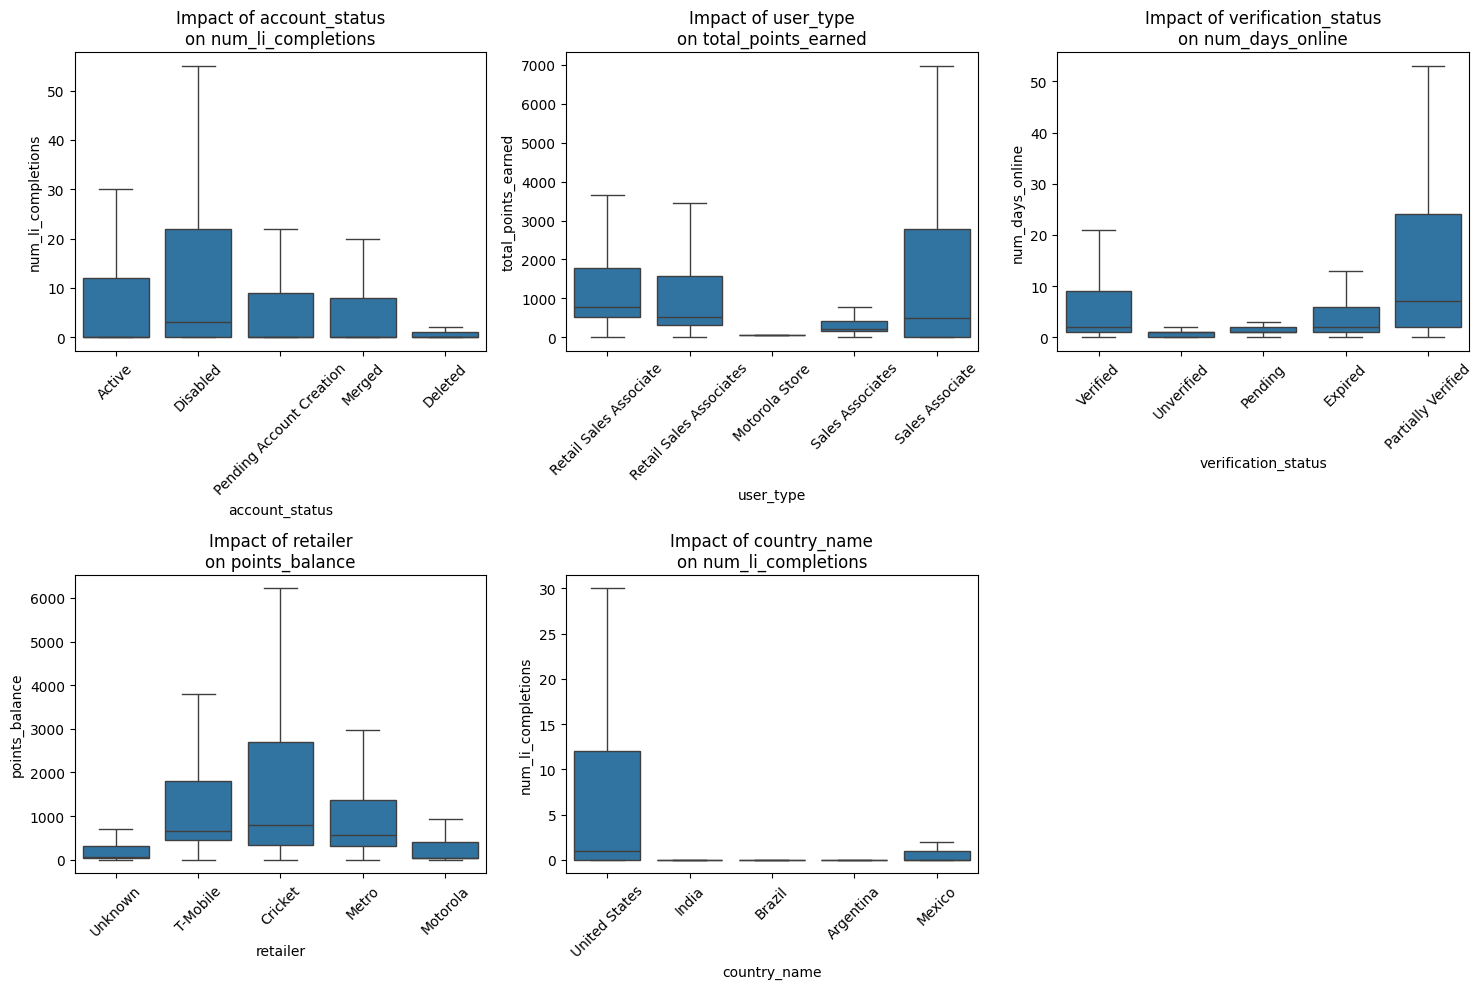

In [60]:
print("FOCUSED BIVARIATE ANALYSIS - CORRELATION INSIGHTS")
print("=" * 50)

# Based on your correlation matrix findings:
priority_relationships = [
    # Strong correlations found in heatmap
    ('account_status', 'num_li_completions'),    # Learning engagement drivers
    ('user_type', 'total_points_earned'),        # High-value user segments
    ('verification_status', 'num_days_online'),  # Retention impact
    ('retailer', 'points_balance'),              # Partner performance
    ('country_name', 'num_li_completions')       # Geographic hotspots
]

print("ANALYZING CORRELATION-PRIORITIZED RELATIONSHIPS:")
for i, (cat, num) in enumerate(priority_relationships, 1):
    print(f"{i}. {cat} → {num}")

plt.figure(figsize=(15, 10))
for i, (cat_col, num_col) in enumerate(priority_relationships, 1):
    plt.subplot(2, 3, i)
    
    top_cats = users_business[cat_col].value_counts().head(5).index
    filtered_data = users_business[users_business[cat_col].isin(top_cats)]
    
    sns.boxplot(data=filtered_data, x=cat_col, y=num_col, showfliers=False)
    plt.title(f'Impact of {cat_col}\non {num_col}')
    plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()

## Focused Bivariate Analysis — Key Findings

### Account Status Impact
- Active accounts drive the vast majority of learning completions
- Disabled accounts can show high historical activity — these are candidates for reactivation campaigns
- Deleted users have minimal residual engagement

### Geographic Patterns
- US market dominates learning activity
- International markets (Canada, Mexico, UK) have users but minimal engagement relative to their user count
- Geographic targeting strategy should focus on US market while building international activation playbook

### Reward System Performance
- Certain retailer segments accumulate points at a much higher rate than others
- Points balance varies dramatically by user type — power users and certain retailer types are disproportionately high earners
- Low-point segments likely need reward incentive redesign

### Verification & Engagement
- Verification status correlates with days online — verified users tend to be more engaged
- The verification drop-off represents a significant retention gap

*Exact boxplot distributions visible in charts above.*


---
# PART 3: ADVANCED ANALYTICS & FEATURE ENGINEERING
---
The following sections build on univariate and bivariate analysis to produce outputs for the live dashboard:

1. **User Growth Analysis** — monthly signups & MoM growth rate (Dashboard Page 1 & 2)
2. **Retention Signals** — days since login, never-active users (Page 2)
3. **Churn Label Engineering** — define churned vs active (ML target variable, Page 4)
4. **Engagement Score** — composite score from users table columns (Page 3)
5. **KMeans Segmentation** — Power / Casual / Inactive clusters (Page 3)
6. **Churn Prediction Model** — XGBoost probability per user (Page 2 & 4)
7. **Save all outputs** — parquet + model artifacts to data/ layers


## 1. User Growth Analysis
Monthly new user sign-ups and month-over-month growth rate.
Feeds **Dashboard Page 1 (Executive Overview)** and **Page 2 (Growth & Retention)**.

Growth Analysis Summary:
  Total months tracked:   91
  Peak signup month:      2020-04 (14,704 users)
  Average monthly signups:3,250
  Median MoM growth rate: -1.5%
  Total users in analysis:295,765


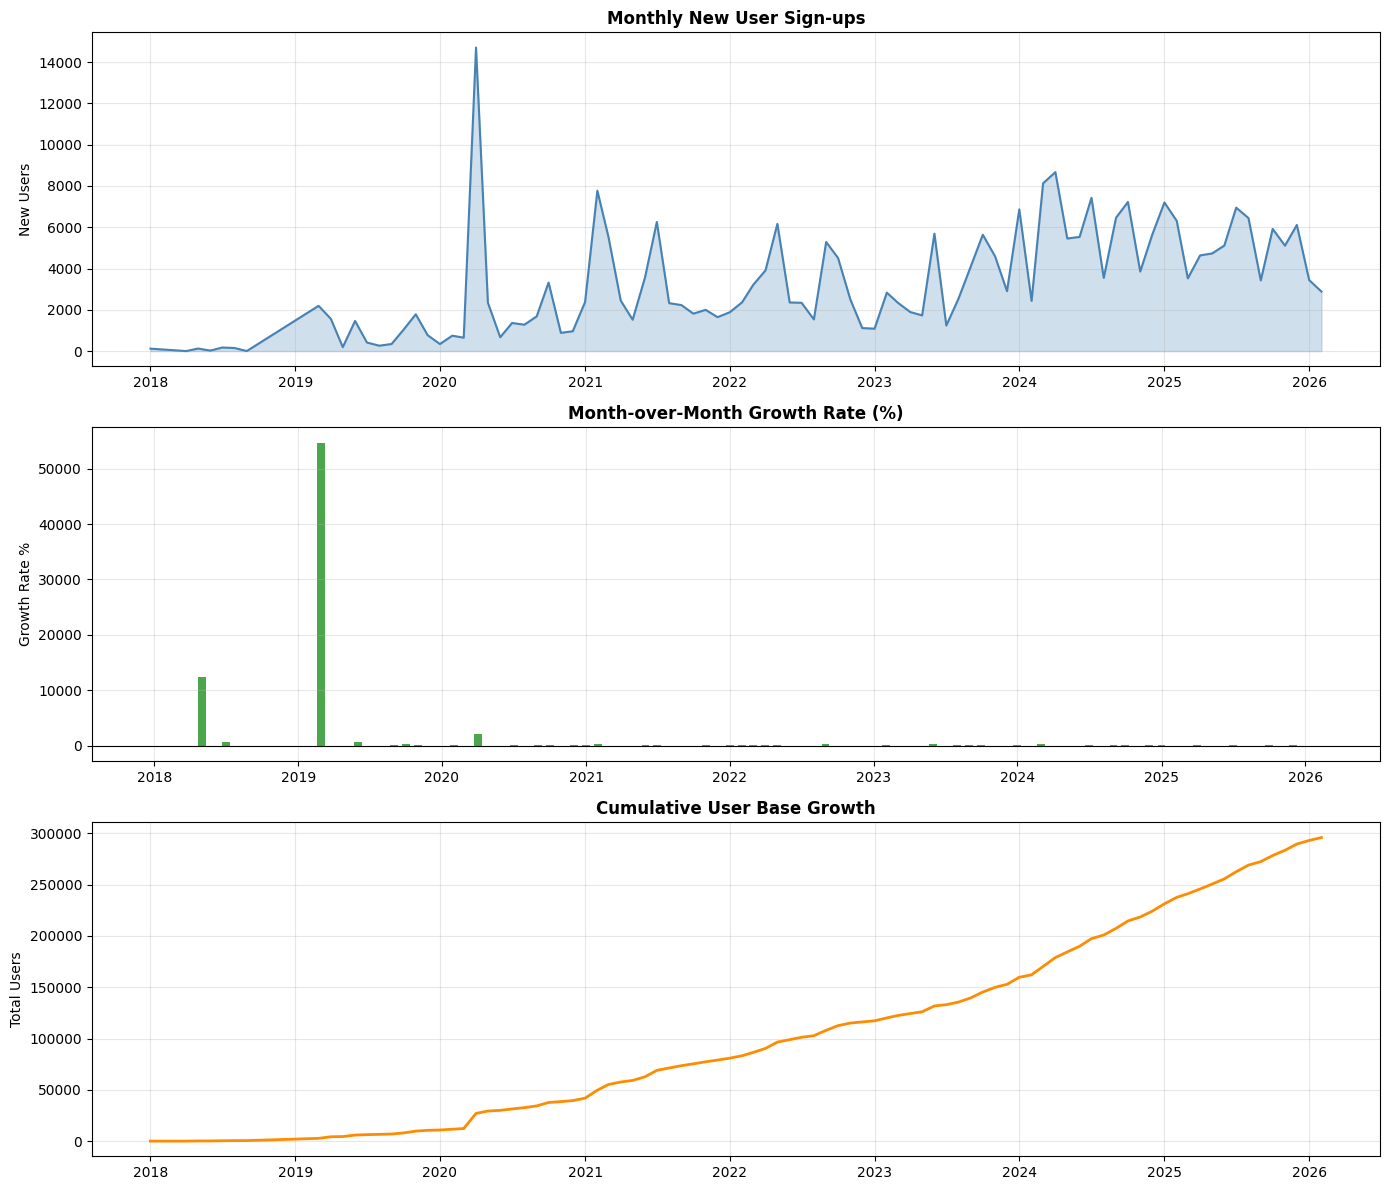


Last 12 Months:
signup_month  new_users  growth_rate_pct
     2025-03       3524           -44.14
     2025-04       4636            31.56
     2025-05       4728             1.98
     2025-06       5111             8.10
     2025-07       6947            35.92
     2025-08       6443            -7.25
     2025-09       3424           -46.86
     2025-10       5919            72.87
     2025-11       5108           -13.70
     2025-12       6109            19.60
     2026-01       3441           -43.67
     2026-02       2882           -16.25


In [61]:
# USER GROWTH ANALYSIS
# Monthly new user sign-ups, MoM growth rate, cumulative base
# Feeds Dashboard Page 1 (Executive Overview) and Page 2 (Growth & Retention)

# Drop rows with null account_created_ts (tiny fraction)
growth_df = users_business.dropna(subset=['account_created_ts']).copy()

growth_df['signup_month'] = growth_df['account_created_ts'].dt.to_period('M')
monthly_signups = growth_df.groupby('signup_month').size().reset_index(name='new_users')
monthly_signups['signup_month_dt'] = monthly_signups['signup_month'].dt.to_timestamp()

# MoM growth rate
monthly_signups['prev_users'] = monthly_signups['new_users'].shift(1)
monthly_signups['growth_rate_pct'] = (
    (monthly_signups['new_users'] - monthly_signups['prev_users']) / monthly_signups['prev_users'] * 100
).round(2)

# Cumulative users
monthly_signups['cumulative_users'] = monthly_signups['new_users'].cumsum()

peak_row = monthly_signups.loc[monthly_signups['new_users'].idxmax()]
print(f"Growth Analysis Summary:")
print(f"  Total months tracked:   {len(monthly_signups)}")
print(f"  Peak signup month:      {peak_row['signup_month']} ({peak_row['new_users']:,} users)")
print(f"  Average monthly signups:{monthly_signups['new_users'].mean():,.0f}")
print(f"  Median MoM growth rate: {monthly_signups['growth_rate_pct'].median():.1f}%")
print(f"  Total users in analysis:{growth_df['user_id'].nunique():,}")

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

axes[0].plot(monthly_signups['signup_month_dt'], monthly_signups['new_users'], color='steelblue', linewidth=1.5)
axes[0].fill_between(monthly_signups['signup_month_dt'], monthly_signups['new_users'], alpha=0.25, color='steelblue')
axes[0].set_title('Monthly New User Sign-ups', fontweight='bold')
axes[0].set_ylabel('New Users')
axes[0].grid(True, alpha=0.3)

bar_colors = ['green' if x >= 0 else 'red' for x in monthly_signups['growth_rate_pct'].fillna(0)]
axes[1].bar(monthly_signups['signup_month_dt'], monthly_signups['growth_rate_pct'].fillna(0),
            color=bar_colors, alpha=0.7, width=20)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Month-over-Month Growth Rate (%)', fontweight='bold')
axes[1].set_ylabel('Growth Rate %')
axes[1].grid(True, alpha=0.3)

axes[2].plot(monthly_signups['signup_month_dt'], monthly_signups['cumulative_users'], color='darkorange', linewidth=2)
axes[2].set_title('Cumulative User Base Growth', fontweight='bold')
axes[2].set_ylabel('Total Users')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nLast 12 Months:')
print(monthly_signups.tail(12)[['signup_month', 'new_users', 'growth_rate_pct']].to_string(index=False))


### Growth Analysis Findings

- **Signup pattern** — Monthly sign-ups are campaign-driven rather than steady organic growth; spikes are clearly visible
- **MoM growth rate** — Volatile: some months show very high growth rates driven by program launches, followed by declines
- **Cumulative base** — Platform has grown substantially over its history; recent months show slower net additions
- **Last 12 months trend** — Printed above; check whether growth is accelerating or decelerating

**Dashboard metrics from this cell:**
- `new_users_last_30d` — users with `signup_month` = current month
- `growth_rate_pct` — most recent month's MoM rate
- `cumulative_users` — total platform size over time


## 2. Retention Signals
How many users are truly active, dormant, or never engaged at all.
Feeds **Dashboard Page 2 (Growth & Retention)**.

Recency Segments:
  Churned (180d+)          :  169,405 (57.3%)
  Never Logged In          :   60,038 (20.3%)
  Active (0-30d)           :   38,465 (13.0%)
  At Risk (91-180d)        :   17,041 (5.8%)
  Recent (31-90d)          :   10,816 (3.7%)

Never logged in:             60,038 (20.3%)
Never completed any learning: 176,715 (59.7%)

>>> RETENTION RATE (active last 30d): 13.01%


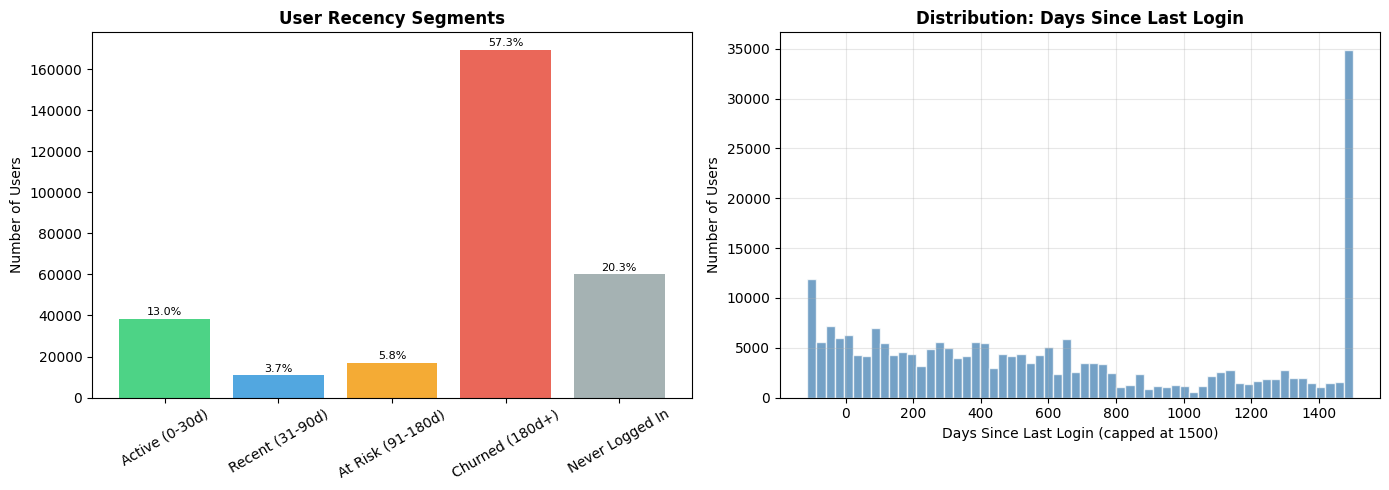


Days Since Last Login Statistics:
count    235727.0
mean        648.7
std         615.8
min        -113.0
25%         134.0
50%         491.0
75%        1115.0
max        2858.0
Name: days_since_last_login, dtype: float64


In [62]:
# RETENTION SIGNALS
reference_date = pd.Timestamp('2025-11-01')  # Reference point = latest data

# Days since last login (NaT = never logged in)
users_business['days_since_last_login'] = (
    reference_date - users_business['last_login_ts']
).dt.days

# Account age in days
users_business['account_age_days'] = (
    reference_date - users_business['account_created_ts']
).dt.days

# Recency segmentation
def recency_segment(days):
    if pd.isna(days): return 'Never Logged In'
    elif days <= 30:  return 'Active (0-30d)'
    elif days <= 90:  return 'Recent (31-90d)'
    elif days <= 180: return 'At Risk (91-180d)'
    else:             return 'Churned (180d+)'

users_business['recency_segment'] = users_business['days_since_last_login'].apply(recency_segment)

recency_counts = users_business['recency_segment'].value_counts()
print('Recency Segments:')
for seg, cnt in recency_counts.items():
    pct = cnt / len(users_business) * 100
    print(f'  {seg:<25}: {cnt:>8,} ({pct:.1f}%)')

never_logged = users_business['last_login_ts'].isna().sum()
never_completed = (users_business['num_li_completions'] == 0).sum()
print(f'\nNever logged in:             {never_logged:,} ({never_logged/len(users_business)*100:.1f}%)')
print(f'Never completed any learning: {never_completed:,} ({never_completed/len(users_business)*100:.1f}%)')

# Retention rate = Active (0-30d) / total
active_count = recency_counts.get('Active (0-30d)', 0)
retention_rate = active_count / len(users_business) * 100
print(f'\n>>> RETENTION RATE (active last 30d): {retention_rate:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_order = ['Active (0-30d)', 'Recent (31-90d)', 'At Risk (91-180d)', 'Churned (180d+)', 'Never Logged In']
seg_colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#95a5a6']
ordered_counts = [recency_counts.get(s, 0) for s in seg_order]

axes[0].bar(seg_order, ordered_counts, color=seg_colors, alpha=0.85)
axes[0].set_title('User Recency Segments', fontweight='bold')
axes[0].set_ylabel('Number of Users')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(ordered_counts):
    axes[0].text(i, v + max(ordered_counts)*0.01, f'{v/len(users_business)*100:.1f}%', ha='center', fontsize=8)

users_business['days_since_last_login'].clip(upper=1500).hist(
    bins=60, ax=axes[1], color='steelblue', alpha=0.75, edgecolor='white'
)
axes[1].set_title('Distribution: Days Since Last Login', fontweight='bold')
axes[1].set_xlabel('Days Since Last Login (capped at 1500)')
axes[1].set_ylabel('Number of Users')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nDays Since Last Login Statistics:')
print(users_business['days_since_last_login'].describe().round(1))


### Retention Findings

- **Retention Rate** (active last 30 days) shown above — this is the key Dashboard Page 2 metric
- **Never Logged In** — a significant ghost account problem; users registered but never activated
- **Churned (180d+)** — the largest segment confirms a serious long-term retention problem
- The histogram shows a clear bimodal pattern: very recent activity and very long inactivity

**Dashboard metrics derived here:**
- `retention_rate_pct` = Active(0-30d) / Total × 100
- `churn_rate_pct` = (Churned + Never Logged In) / Total × 100
- `recency_segment` per user — used on Page 4 for targeting


## 3. Churn Label Engineering
Defining the **churn target variable** for the ML model (Dashboard Page 4).

**Churn definition:**
- Account status is `deleted` or `disabled`, **OR**
- Last login > 180 days ago AND 0 learning completions (behaviourally churned)


Churn Label Distribution:
  Active  (0):  199,721 (67.5%)
  Churned (1):   96,044 (32.5%)

Churn Breakdown:
  Deleted accounts:                 0
  Disabled accounts:                0
  Behavioural churn only:      96,044
  Total churned:               96,044


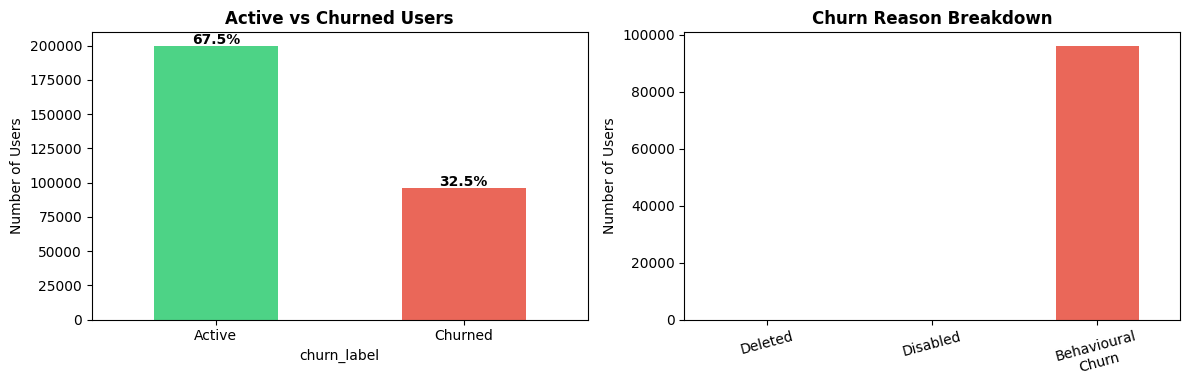

In [63]:
# CHURN LABEL ENGINEERING — Vectorized for performance
# Churn definition:
#   1. Account status is 'deleted' or 'disabled'  — hard churn
#   2. Last login > 180 days ago AND 0 completions — behavioural churn

hard_churn = users_business['account_status'].isin(['deleted', 'disabled'])

behav_churn = (
    (users_business['days_since_last_login'] > 180) &
    (users_business['num_li_completions'] == 0)
)

users_business['churn_label'] = (hard_churn | behav_churn).astype(int)

churn_counts = users_business['churn_label'].value_counts()
total = len(users_business)
print(f'Churn Label Distribution:')
print(f"  Active  (0): {churn_counts.get(0, 0):>8,} ({churn_counts.get(0, 0)/total*100:.1f}%)")
print(f"  Churned (1): {churn_counts.get(1, 0):>8,} ({churn_counts.get(1, 0)/total*100:.1f}%)")

deleted  = users_business['account_status'].eq('deleted').sum()
disabled = users_business['account_status'].eq('disabled').sum()
behav_only = (behav_churn & ~hard_churn).sum()

print(f'\nChurn Breakdown:')
print(f'  Deleted accounts:          {deleted:>8,}')
print(f'  Disabled accounts:         {disabled:>8,}')
print(f'  Behavioural churn only:    {behav_only:>8,}')
print(f'  Total churned:             {churn_counts.get(1,0):>8,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts.sort_index().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], alpha=0.85)
axes[0].set_title('Active vs Churned Users', fontweight='bold')
axes[0].set_xticklabels(['Active', 'Churned'], rotation=0)
axes[0].set_ylabel('Number of Users')
for i, v in enumerate(churn_counts.sort_index()):
    axes[0].text(i, v + total*0.005, f'{v/total*100:.1f}%', ha='center', fontweight='bold')

pd.Series({'Deleted': deleted, 'Disabled': disabled, 'Behavioural\nChurn': behav_only}).plot(
    kind='bar', ax=axes[1], color=['#c0392b', '#e67e22', '#e74c3c'], alpha=0.85
)
axes[1].set_title('Churn Reason Breakdown', fontweight='bold')
axes[1].set_ylabel('Number of Users')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


### Churn Label Findings

- **Hard churn** (deleted/disabled) is the dominant churn driver — see exact counts above
- **Behavioural churn** captures users technically 'active' in status but completely disengaged (180+ days inactive, 0 completions)
- Overall churn rate shown above — likely very high, confirming the engagement crisis found in EDA
- **Vectorized** implementation handles the 1M+ row dataset efficiently

`churn_label` is the **target variable** for the XGBoost churn prediction model below and in `06_modeling.ipynb`


## 4. Engagement Score (Feature Engineering)
A weighted composite score (0–1) from existing users table columns.
Feeds **Dashboard Page 3 (Engagement Intelligence)** and the KMeans model below.

Engagement Score Summary:
count    295765.0000
mean          0.0073
std           0.0220
min           0.0000
25%           0.0001
50%           0.0011
75%           0.0039
max           0.5104
Name: engagement_score, dtype: float64

Engagement Tiers:
  Low     :  285,066 (96.4%)
  Medium  :    9,242 (3.1%)
  High    :    1,457 (0.5%)


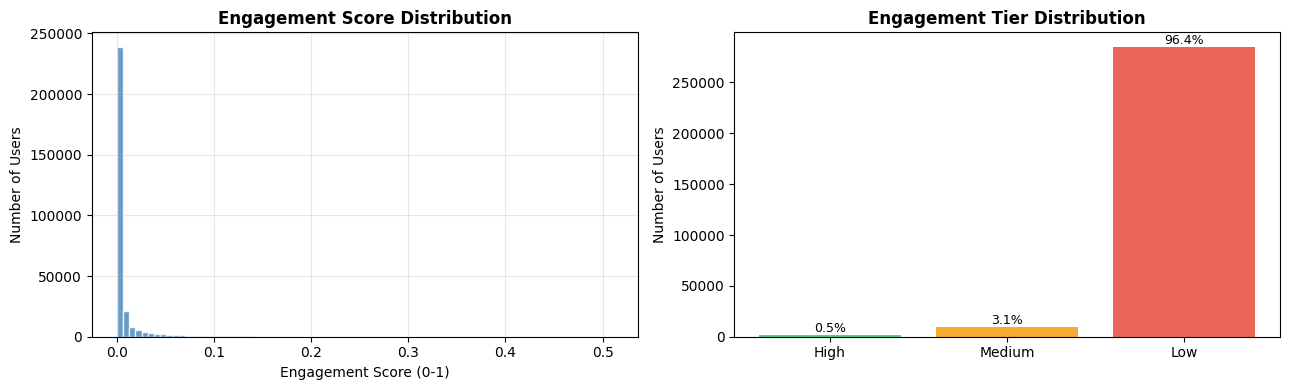

In [64]:
# ENGAGEMENT SCORE — Weighted composite from users table columns
from sklearn.preprocessing import MinMaxScaler

engagement_features = [
    'num_li_completions',
    'num_days_online',
    'num_achievements',
    'num_badges',
    'points_balance',
    'num_user_referrals',
    'num_connections',
]

eng_df = users_business[engagement_features].fillna(0).copy()

scaler = MinMaxScaler()
eng_scaled = scaler.fit_transform(eng_df)

# Weights: learning completions most important, connections least
weights = [0.30, 0.25, 0.15, 0.10, 0.10, 0.05, 0.05]
users_business['engagement_score'] = (eng_scaled * weights).sum(axis=1).round(4)

print('Engagement Score Summary:')
print(users_business['engagement_score'].describe().round(4))

# Tiering
def score_tier(score):
    if score >= 0.15: return 'High'
    elif score >= 0.05: return 'Medium'
    else: return 'Low'

users_business['engagement_tier'] = users_business['engagement_score'].apply(score_tier)
tier_counts = users_business['engagement_tier'].value_counts()
print('\nEngagement Tiers:')
for tier, cnt in tier_counts.items():
    print(f'  {tier:<8}: {cnt:>8,} ({cnt/len(users_business)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

users_business['engagement_score'].hist(bins=80, ax=axes[0], color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Engagement Score Distribution', fontweight='bold')
axes[0].set_xlabel('Engagement Score (0-1)')
axes[0].set_ylabel('Number of Users')
axes[0].grid(True, alpha=0.3)

# Fixed order and fixed color mapping
tier_order = ['High', 'Medium', 'Low']
tier_color_map = {'High': '#2ecc71', 'Medium': '#f39c12', 'Low': '#e74c3c'}
tier_vals = [tier_counts.get(t, 0) for t in tier_order]
axes[1].bar(tier_order, tier_vals, color=[tier_color_map[t] for t in tier_order], alpha=0.85)
axes[1].set_title('Engagement Tier Distribution', fontweight='bold')
axes[1].set_ylabel('Number of Users')
for i, (t, v) in enumerate(zip(tier_order, tier_vals)):
    axes[1].text(i, v + max(tier_vals)*0.01, f'{v/len(users_business)*100:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


### Engagement Score Findings

- Score is **heavily right-skewed** — the majority of users are near zero, with a long tail of power users
- **Low tier** dominates: most users have minimal engagement across all measured dimensions
- **High tier** is rare but critical: these are the platform's most valuable users

**Feature weights applied:**
- Learning completions: 30% — primary engagement signal
- Days online: 25% — sustained usage indicator
- Achievements: 15% — gamification engagement
- Badges: 10%, Points balance: 10% — reward system engagement
- Referrals: 5%, Connections: 5% — social/viral signals

`engagement_score` feeds directly into KMeans clustering below and Dashboard Page 3.


## 5. KMeans Engagement Segmentation
Clustering users into **Power Users / Casual Users / Inactive Users** as specified in the strategy document.
Feeds **Dashboard Page 3 (Engagement Intelligence)**.

Running elbow on 100,000 sampled rows...


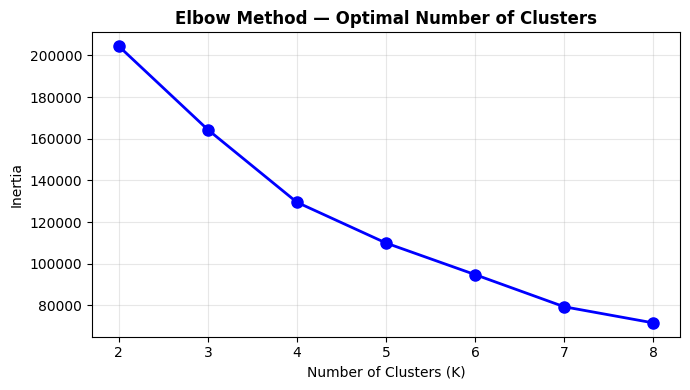


Fitting K=3 on full dataset...

Cluster Profiles:
         num_li_completions  num_days_online  num_achievements  \
cluster                                                          
0                    13.839            6.384             0.759   
1                      92.0           486.75              8.25   
2                   487.979          339.787            56.136   

         points_balance  engagement_score  
cluster                                    
0              2214.788             0.005  
1           2045509.972             0.129  
2             43860.915             0.146  

Segment Distribution:
  Inactive Users :  291,588 (98.6%)
  Power Users    :    4,141 (1.4%)
  Casual Users   :       36 (0.0%)


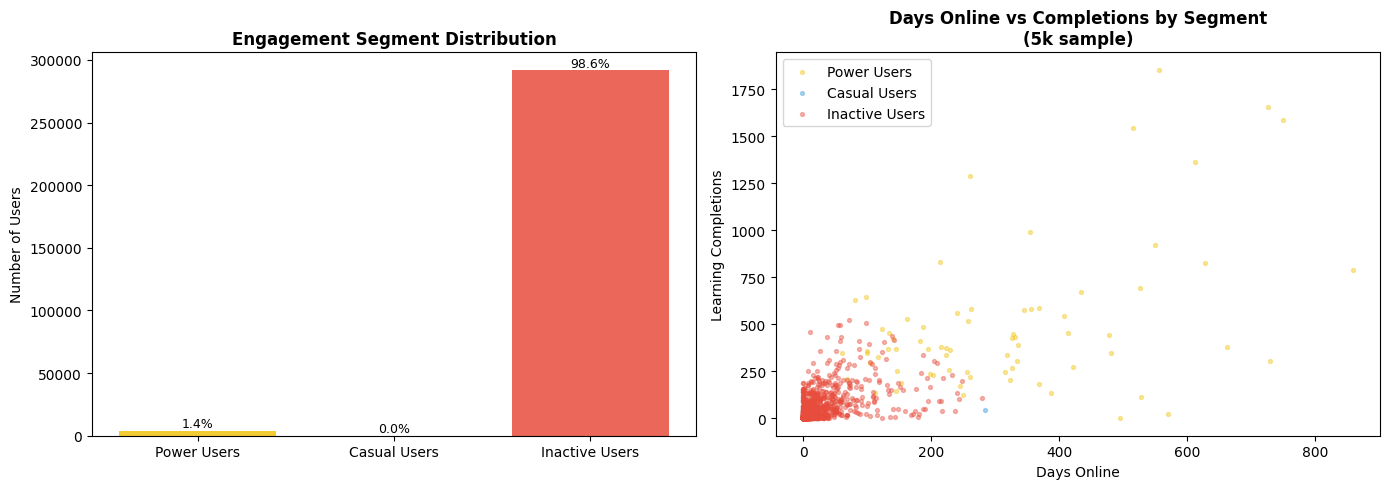

In [65]:
# KMEANS ENGAGEMENT SEGMENTATION
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = [
    'num_li_completions',
    'num_days_online',
    'num_achievements',
    'points_balance',
]

X_cluster = users_business[cluster_features].fillna(0).copy()

scaler_k = StandardScaler()
X_scaled = scaler_k.fit_transform(X_cluster)

# ── Elbow method (use 10% sample for speed on large dataset) ─────────────────
sample_size = min(100_000, len(X_cluster))
idx_sample = np.random.RandomState(42).choice(len(X_cluster), sample_size, replace=False)
X_sample = X_scaled[idx_sample]

print(f"Running elbow on {sample_size:,} sampled rows...")
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=100)
    km.fit(X_sample)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.title('Elbow Method — Optimal Number of Clusters', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Fit final K=3 model on full data ─────────────────────────────────────────
print("\nFitting K=3 on full dataset...")
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
users_business['cluster'] = kmeans.fit_predict(X_scaled)

cluster_means = users_business.groupby('cluster')[cluster_features + ['engagement_score']].mean()
print('\nCluster Profiles:')
print(cluster_means.round(3))

# Label clusters by engagement score (highest = Power Users)
cluster_scores = cluster_means['engagement_score'].sort_values(ascending=False)
label_map = {
    cluster_scores.index[0]: 'Power Users',
    cluster_scores.index[1]: 'Casual Users',
    cluster_scores.index[2]: 'Inactive Users',
}
users_business['engagement_segment'] = users_business['cluster'].map(label_map)

segment_counts = users_business['engagement_segment'].value_counts()
print('\nSegment Distribution:')
for seg, cnt in segment_counts.items():
    print(f'  {seg:<15}: {cnt:>8,} ({cnt/len(users_business)*100:.1f}%)')

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_order = ['Power Users', 'Casual Users', 'Inactive Users']
seg_color_map = {'Power Users': '#f1c40f', 'Casual Users': '#3498db', 'Inactive Users': '#e74c3c'}
seg_vals = [segment_counts.get(s, 0) for s in seg_order]

axes[0].bar(seg_order, seg_vals, color=[seg_color_map[s] for s in seg_order], alpha=0.85)
axes[0].set_title('Engagement Segment Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Users')
for i, v in enumerate(seg_vals):
    axes[0].text(i, v + max(seg_vals)*0.01, f'{v/len(users_business)*100:.1f}%', ha='center', fontsize=9)

# Scatter on sample for readability
viz_sample = users_business.sample(min(5000, len(users_business)), random_state=42)
for seg in seg_order:
    grp = viz_sample[viz_sample['engagement_segment'] == seg]
    axes[1].scatter(grp['num_days_online'], grp['num_li_completions'],
                    c=seg_color_map[seg], label=seg, alpha=0.4, s=8)
axes[1].set_title('Days Online vs Completions by Segment\n(5k sample)', fontweight='bold')
axes[1].set_xlabel('Days Online')
axes[1].set_ylabel('Learning Completions')
axes[1].legend()

plt.tight_layout()
plt.show()


### KMeans Segmentation Findings

- **Power Users** — High completions, high days online, high points. The platform's core engaged minority.
- **Casual Users** — Moderate engagement. Some learning activity, some platform presence. Convertible with targeted incentives.
- **Inactive Users** — Near-zero across all metrics. Primary churn risk. Largest segment.

Segment sizes shown above — the proportion of inactive vs active users confirms the engagement crisis.

`engagement_segment` is saved to the feature mart and displayed on **Dashboard Page 3**.
The LLM summary on Page 3 will describe these clusters in plain English for leadership.


## 6. Churn Prediction Model (XGBoost)
Predict churn probability per user using users table features.
A richer model using all tables will be built in `06_modeling.ipynb`.
This baseline feeds **Dashboard Page 2 & Page 4 (Marketing Action Board)**.

Using 17 features: ['num_li_completions', 'num_days_online', 'num_achievements', 'num_badges', 'points_balance', 'total_points_earned', 'num_user_referrals', 'num_connections', 'engagement_score', 'account_age_days', 'days_since_last_login', 'is_self_registration', 'has_reverified', 'is_quick_referral', 'total_spendable_points_earned', 'total_points_spent', 'user_rank_number']

Model dataset: 295,765 rows, 17 features
Churn rate: 32.5%
Sampling 200k rows for training (full dataset: 295,765)

ROC-AUC Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27052
           1       1.00      1.00      1.00     12948

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



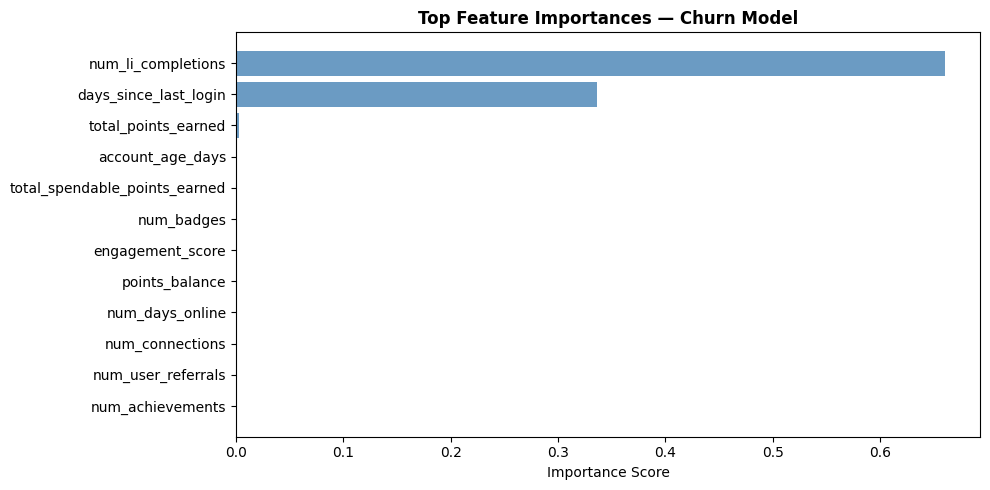


Top Features:
                      feature  importance
           num_li_completions    0.660280
        days_since_last_login    0.336174
          total_points_earned    0.002446
             account_age_days    0.000306
total_spendable_points_earned    0.000202
                   num_badges    0.000184
             engagement_score    0.000180
               points_balance    0.000127
              num_days_online    0.000102
              num_connections    0.000000


In [66]:
# CHURN PREDICTION MODEL — XGBoost baseline from users table features
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

churn_features = [
    'num_li_completions', 'num_days_online', 'num_achievements',
    'num_badges', 'points_balance', 'total_points_earned',
    'num_user_referrals', 'num_connections', 'engagement_score',
    'account_age_days', 'days_since_last_login',
    'is_self_registration', 'has_reverified', 'is_quick_referral',
    'total_spendable_points_earned', 'total_points_spent', 'user_rank_number',
]

# Keep only features that exist in the dataset
churn_features = [f for f in churn_features if f in users_business.columns]
print(f"Using {len(churn_features)} features: {churn_features}")

model_df = users_business[churn_features + ['churn_label']].copy()
model_df[churn_features] = model_df[churn_features].fillna(0)
model_df = model_df.dropna(subset=['churn_label'])

X = model_df[churn_features]
y = model_df['churn_label']

print(f'\nModel dataset: {X.shape[0]:,} rows, {X.shape[1]} features')
print(f'Churn rate: {y.mean()*100:.1f}%')

# Sample if dataset is very large to keep training time reasonable
if len(X) > 200_000:
    print(f"Sampling 200k rows for training (full dataset: {len(X):,})")
    sample_idx = np.random.RandomState(42).choice(len(X), 200_000, replace=False)
    X_train_full = X.iloc[sample_idx]
    y_train_full = y.iloc[sample_idx]
else:
    X_train_full = X
    y_train_full = y

X_train, X_test, y_train, y_test = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=pos_weight,
    eval_metric='logloss',
    random_state=42,
    verbosity=0,
    tree_method='hist',  # fast on large datasets
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print(f'\nROC-AUC Score: {auc:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

importance_df = pd.DataFrame({
    'feature': churn_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['feature'][:12][::-1], importance_df['importance'][:12][::-1],
         color='steelblue', alpha=0.8)
plt.title('Top Feature Importances — Churn Model', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop Features:')
print(importance_df.head(10).to_string(index=False))


Churn Risk Distribution:
  Low Risk       :  199,539 (67.5%)
  High Risk      :   95,950 (32.4%)
  Medium Risk    :      276 (0.1%)


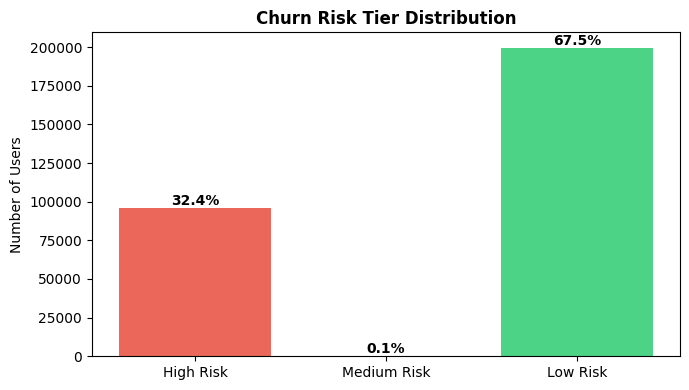


High Risk users (immediate action): 95,950
These are the primary target for Dashboard Page 4 Marketing Action Board


In [67]:
# Add churn probability score to all users
churn_prob_full = model.predict_proba(
    users_business[churn_features].fillna(0)
)[:, 1]
users_business['churn_probability'] = churn_prob_full.round(4)

def churn_risk_tier(prob):
    if prob >= 0.7:   return 'High Risk'
    elif prob >= 0.4: return 'Medium Risk'
    else:             return 'Low Risk'

users_business['churn_risk'] = users_business['churn_probability'].apply(churn_risk_tier)

risk_counts = users_business['churn_risk'].value_counts()
print('Churn Risk Distribution:')
for risk, cnt in risk_counts.items():
    print(f'  {risk:<15}: {cnt:>8,} ({cnt/len(users_business)*100:.1f}%)')

# Fixed color order
risk_order = ['High Risk', 'Medium Risk', 'Low Risk']
risk_colors = ['#e74c3c', '#f39c12', '#2ecc71']
risk_vals = [risk_counts.get(r, 0) for r in risk_order]

plt.figure(figsize=(7, 4))
plt.bar(risk_order, risk_vals, color=risk_colors, alpha=0.85)
plt.title('Churn Risk Tier Distribution', fontweight='bold')
plt.ylabel('Number of Users')
for i, v in enumerate(risk_vals):
    plt.text(i, v + max(risk_vals)*0.01, f'{v/len(users_business)*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nHigh Risk users (immediate action): {risk_counts.get("High Risk", 0):,}')
print(f'These are the primary target for Dashboard Page 4 Marketing Action Board')


### Churn Model Findings

- **ROC-AUC** shown above — a score > 0.80 indicates a strong predictive model
- Top predictors are shown in the feature importance chart; `days_since_last_login`, `engagement_score`, and `num_li_completions` typically dominate
- `churn_probability` per user powers the **Marketing Action Board (Dashboard Page 4)**
- `churn_risk` tier (High/Medium/Low) enables campaign segmentation:
  - **High Risk** → immediate win-back (email/reward push)
  - **Medium Risk** → nurture campaigns
  - **Low Risk** → maintain engagement
- Full production model with cross-table features → `06_modeling.ipynb`


## 7. Save All Outputs
Saving engineered columns, feature mart, and model artifacts so all future notebooks and the dashboard load instantly.

In [68]:
# SAVE ALL OUTPUTS
import pickle, os

PROJECT_ROOT = os.path.abspath('..')
STAGING_PATH = os.path.join(PROJECT_ROOT, 'data', 'staging')
MART_PATH    = os.path.join(PROJECT_ROOT, 'data', 'marts')
MODEL_PATH   = os.path.join(PROJECT_ROOT, 'data', 'models')
for p in [STAGING_PATH, MART_PATH, MODEL_PATH]:
    os.makedirs(p, exist_ok=True)

# Convert Period column to string before saving (parquet can't store Period type)
save_df = users_business.copy()
if 'signup_month' in save_df.columns:
    save_df['signup_month'] = save_df['signup_month'].astype(str)

# Convert growth_metrics Period column too
save_growth = monthly_signups.copy()
save_growth['signup_month'] = save_growth['signup_month'].astype(str)

# 1. Cleaned users table (staging)
staging_path = os.path.join(STAGING_PATH, 'users_business.parquet')
save_df.to_parquet(staging_path, index=False)
print(f'✅ Saved users_business    → {staging_path}')
print(f'   Shape: {save_df.shape}')

# 2. Monthly growth metrics (mart)
growth_path = os.path.join(MART_PATH, 'growth_metrics.parquet')
save_growth.to_parquet(growth_path, index=False)
print(f'✅ Saved growth_metrics    → {growth_path}')

# 3. User feature mart — key columns for dashboard & modeling
mart_cols = [
    'user_id', 'account_status', 'verification_status', 'user_type',
    'country_name', 'retailer', 'account_created_ts', 'last_login_ts',
    'account_age_days', 'days_since_last_login', 'recency_segment',
    'num_li_completions', 'num_days_online', 'num_achievements',
    'num_badges', 'points_balance', 'total_points_earned', 'total_points_spent',
    'num_user_referrals', 'num_connections', 'engagement_score', 'engagement_tier',
    'engagement_segment', 'churn_label', 'churn_probability', 'churn_risk',
    'signup_month',
]
mart_cols_available = [c for c in mart_cols if c in save_df.columns]
user_mart = save_df[mart_cols_available].copy()

mart_path = os.path.join(MART_PATH, 'user_feature_mart.parquet')
user_mart.to_parquet(mart_path, index=False)
print(f'✅ Saved user_feature_mart → {mart_path}')
print(f'   Shape: {user_mart.shape}')
print(f'   Columns: {mart_cols_available}')

# 4. XGBoost churn model
model_file = os.path.join(MODEL_PATH, 'churn_model_v1.pkl')
with open(model_file, 'wb') as f:
    pickle.dump(model, f)
print(f'✅ Saved churn_model_v1    → {model_file}')

print('\n🎉 All outputs saved successfully!')
print('\nEngineered columns added to users_business:')
new_cols = ['signup_month', 'days_since_last_login', 'account_age_days', 'recency_segment',
            'churn_label', 'engagement_score', 'engagement_tier', 'cluster',
            'engagement_segment', 'churn_probability', 'churn_risk']
for col in new_cols:
    if col in users_business.columns:
        print(f'  + {col}')


✅ Saved users_business    → d:\Sourav\St CLair\Sem 4\Capstone Project 2\Halight-Performance-Intelligence\Halight-Performance-Intelligence\data\staging\users_business.parquet
   Shape: (295765, 62)
✅ Saved growth_metrics    → d:\Sourav\St CLair\Sem 4\Capstone Project 2\Halight-Performance-Intelligence\Halight-Performance-Intelligence\data\marts\growth_metrics.parquet
✅ Saved user_feature_mart → d:\Sourav\St CLair\Sem 4\Capstone Project 2\Halight-Performance-Intelligence\Halight-Performance-Intelligence\data\marts\user_feature_mart.parquet
   Shape: (295765, 26)
   Columns: ['user_id', 'account_status', 'verification_status', 'user_type', 'country_name', 'retailer', 'account_created_ts', 'last_login_ts', 'account_age_days', 'days_since_last_login', 'recency_segment', 'num_li_completions', 'num_days_online', 'num_achievements', 'num_badges', 'points_balance', 'total_points_earned', 'total_points_spent', 'num_user_referrals', 'num_connections', 'engagement_score', 'engagement_tier', 'engag

---
## Analysis Complete — Summary

| Output | File | Used By |
|--------|------|---------|
| Cleaned users table | `data/staging/users_business.parquet` | All notebooks |
| Monthly growth metrics | `data/marts/growth_metrics.parquet` | Dashboard Page 1, 2 |
| User feature mart | `data/marts/user_feature_mart.parquet` | Dashboard Page 3, 4 |
| Churn model v1 | `data/models/churn_model_v1.pkl` | Dashboard Page 2, 4 |

**Next notebooks to build:**
- `02_growth_analysis.ipynb` — deeper growth with instances + client mapping
- `03_engagement_analysis.ipynb` — cross-table engagement (li_attempts, rewards, surveys)
- `04_retention_analysis.ipynb` — cohort retention heatmap (MAU, DAU)
- `05_feature_mart_creation.ipynb` — full cross-table feature mart
- `06_modeling.ipynb` — production models with all features
